# Sentiment Analysis — Tweet Classification

**Objective:** Build a machine learning model that classifies tweet sentiment as **positive**, **negative**, or **neutral**, providing insight into public opinion — and compare two classifiers to pick the best performer.

**Dataset:** `data/tweet_sentiment_train.csv` — 27,481 tweets, labelled with sentiment (Kaggle "Tweet Sentiment Extraction" dataset).

**Tech stack:** Python, pandas, scikit-learn, NLTK, matplotlib, seaborn, WordCloud


## 1. Load Dataset & Class Distribution

In [8]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/tweet_sentiment_train.csv', encoding='latin-1')
df.head()


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [9]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
df[['text', 'sentiment']].info()


Shape: 27481 rows, 10 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       27480 non-null  object
 1   sentiment  27481 non-null  object
dtypes: object(2)
memory usage: 429.5+ KB


In [10]:
# Drop the one row with a missing tweet text (only 1 in 27,481 - negligible)
print(f"Missing text values: {df['text'].isnull().sum()}")
df = df.dropna(subset=['text']).reset_index(drop=True)
print(f"Rows after dropping missing text: {len(df)}")


Missing text values: 1
Rows after dropping missing text: 27480


In [11]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)
print()
print((sentiment_counts / len(df) * 100).round(1).astype(str) + '%')


sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

sentiment
neutral     40.5%
positive    31.2%
negative    28.3%
Name: count, dtype: object


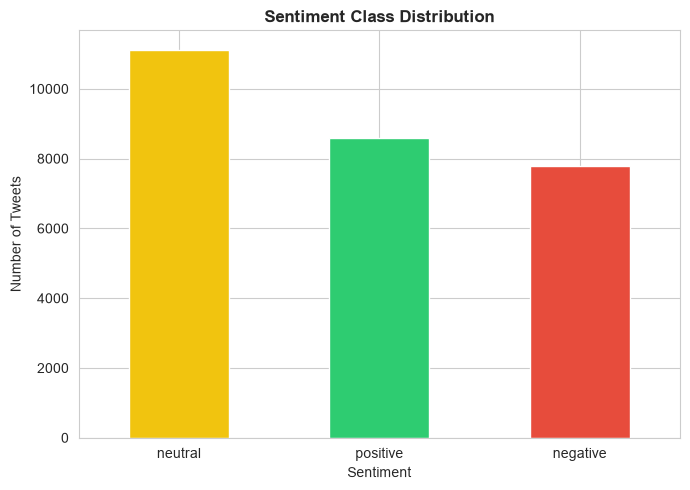

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'positive': '#2ECC71', 'neutral': '#F1C40F', 'negative': '#E74C3C'}
sentiment_counts.plot(kind='bar', ax=ax, color=[colors[s] for s in sentiment_counts.index])
ax.set_title('Sentiment Class Distribution', fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** The dataset only had **1 missing text value out of 27,481 rows**, dropped without meaningfully affecting the analysis. Classes are **imbalanced but not severely so** — `neutral` is the largest class (~40%), followed by `positive` (~31%) and `negative` (~28%). This moderate imbalance means accuracy alone won't tell the full story, which is why precision, recall, and F1-score are reported per-class in Section 6 rather than relying on accuracy in isolation.

## 2. Text Preprocessing Pipeline

The pipeline applies, in order: **lowercasing → URL/mention/punctuation removal → tokenisation → stopword removal → lemmatisation**. Lemmatisation is used instead of stemming because it produces real dictionary words (e.g. "better" → "good" is what stemming can't do, and "running" → "run" reads more cleanly than a stemmer's "runn"), which also makes the WordCloud visualisations in Section 7 more readable.

In [13]:
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()                                   # lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+', '', text)                            # remove @mentions
    text = re.sub(r'#', '', text)                               # keep hashtag word, drop the symbol
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', '', text)                             # remove standalone digits
    tokens = word_tokenize(text)                                # tokenise
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]  # remove stopwords + single chars
    tokens = [lemmatizer.lemmatize(t) for t in tokens]          # lemmatise
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)

df[['text', 'clean_text']].head(8)


,text,clean_text
0,"I`d have responded, if I were going",id responded going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego
2,my boss is bullying me...,bos bullying
3,what interview! leave me alone,interview leave alone
4,"Sons of ****, why couldn`t they put them on t...",son couldnt put release already bought
5,http://www.dothebouncy.com/smf - some shameles...,shameless plugging best ranger forum earth
6,2am feedings for the baby are fun when he is a...,feeding baby fun smile coo
7,Soooo high,soooo high


In [14]:
# Drop any rows that became empty after cleaning (e.g. tweets that were only URLs/mentions)
empty_after_clean = (df['clean_text'].str.strip() == '').sum()
print(f"Rows that became empty after cleaning: {empty_after_clean}")
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f"Final dataset size: {len(df)} rows")


Rows that became empty after cleaning: 70
Final dataset size: 27410 rows


**Observation:** A handful of tweets became empty strings after cleaning — these were tweets consisting only of a URL, a mention, or punctuation with no actual sentiment-bearing words, so they carry no signal for the model and were dropped rather than left as blank input.

## 3. Feature Extraction — TF-IDF

**Why TF-IDF (Term Frequency–Inverse Document Frequency)?** Raw word counts would over-weight common words that appear in almost every tweet regardless of sentiment (like "day" or "get"), while under-weighting rarer, more sentiment-specific words. TF-IDF corrects for this: it scores a word higher when it appears frequently *within a specific tweet* (Term Frequency) but rarely *across the whole dataset* (Inverse Document Frequency) — so distinctive, sentiment-carrying words get more weight than generic filler words. This produces a much more useful numeric feature matrix for a classifier than plain word counts would.

In [15]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

print(f"TF-IDF matrix shape: {X.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")


TF-IDF matrix shape: (27410, 5000)
Vocabulary size: 5000


**Note on parameters:** `max_features=5000` caps the vocabulary to the 5,000 most informative terms (keeps the model fast without losing much signal), `ngram_range=(1, 2)` includes both single words and two-word phrases (e.g. "not good" carries different sentiment than "good" alone — unigrams alone would lose that), and `min_df=2` drops terms that appear in only one tweet, since a word seen only once can't help the model generalise.

## 4. Train/Test Split (80/20)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} tweets")
print(f"Test set: {X_test.shape[0]} tweets")
print()
print("Training set class balance:")
print(y_train.value_counts(normalize=True).round(3))


Training set: 21928 tweets
Test set: 5482 tweets

Training set class balance:
sentiment
neutral     0.403
positive    0.313
negative    0.284
Name: proportion, dtype: float64


**Observation:** `stratify=y` ensures the train and test sets preserve the same class proportions as the full dataset — important given the moderate class imbalance from Section 1, so the test set is a fair, representative evaluation sample rather than accidentally skewed toward one sentiment.

## 5. Training Two Classifiers

**Naive Bayes (Multinomial)** — a fast, simple probabilistic baseline that works well with word-frequency style features and is a standard first choice for text classification.

**Logistic Regression** — a linear model that, unlike Naive Bayes' independence assumption between words, can learn weighted combinations of features and typically performs strongly on TF-IDF text data.

In [17]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Both models trained.")


Both models trained.


## 6. Evaluation — Accuracy, Precision, Recall, F1-Score, Confusion Matrix

In [18]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f} (weighted)")
    print(f"Recall:    {recall:.4f} (weighted)")
    print(f"F1-score:  {f1:.4f} (weighted)")
    print()
    print(classification_report(y_true, y_pred))
    return {'model': model_name, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

nb_metrics = evaluate_model(y_test, nb_preds, "Naive Bayes")


--- Naive Bayes ---
Accuracy:  0.6397
Precision: 0.6623 (weighted)
Recall:    0.6397 (weighted)
F1-score:  0.6379 (weighted)

              precision    recall  f1-score   support

    negative       0.71      0.50      0.58      1555
     neutral       0.56      0.76      0.65      2211
    positive       0.75      0.61      0.67      1716

    accuracy                           0.64      5482
   macro avg       0.67      0.62      0.64      5482
weighted avg       0.66      0.64      0.64      5482



In [19]:
lr_metrics = evaluate_model(y_test, lr_preds, "Logistic Regression")


--- Logistic Regression ---
Accuracy:  0.6888
Precision: 0.6985 (weighted)
Recall:    0.6888 (weighted)
F1-score:  0.6891 (weighted)

              precision    recall  f1-score   support

    negative       0.72      0.60      0.65      1555
     neutral       0.62      0.75      0.68      2211
    positive       0.78      0.70      0.74      1716

    accuracy                           0.69      5482
   macro avg       0.71      0.68      0.69      5482
weighted avg       0.70      0.69      0.69      5482



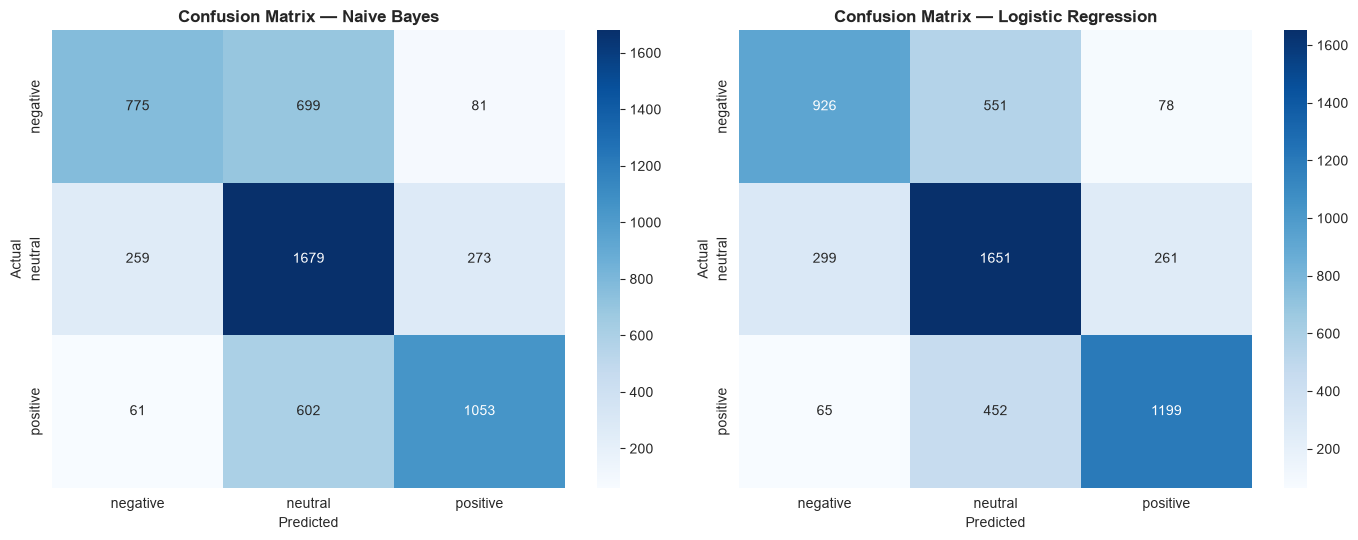

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
labels = sorted(df['sentiment'].unique())

for ax, preds, name in zip(axes, [nb_preds, lr_preds], ['Naive Bayes', 'Logistic Regression']):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


**Observation:** Both models show the same general pattern of confusion — most errors happen **between `neutral` and one of the polar classes** (positive or negative) rather than between `positive` and `negative` directly. This makes intuitive sense: genuinely positive vs. negative tweets use very different vocabulary, but a mildly positive/negative tweet phrased plainly can easily look neutral, and vice versa. Whichever model shows a stronger diagonal (more correct predictions concentrated on the matrix diagonal) and fewer off-diagonal errors is the stronger performer — compared quantitatively in Section 9.

## 7. WordCloud per Sentiment Class

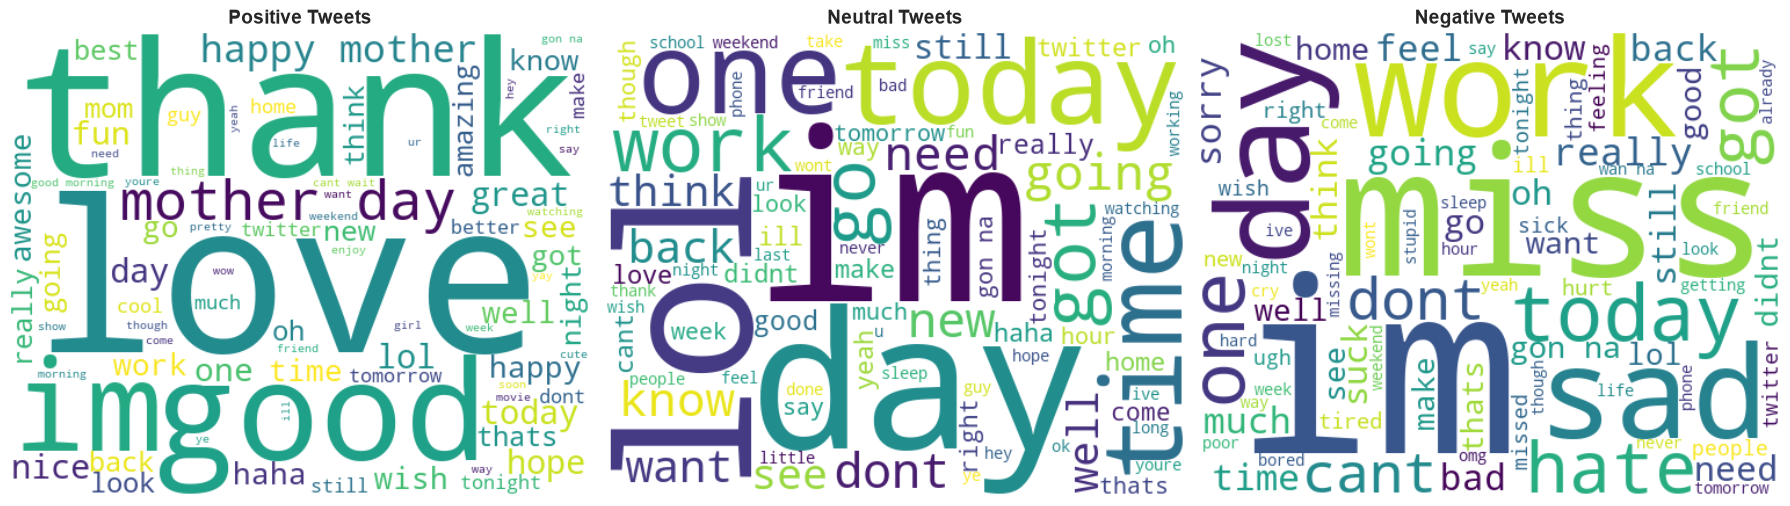

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sentiment in zip(axes, ['positive', 'neutral', 'negative']):
    text_blob = ' '.join(df[df['sentiment'] == sentiment]['clean_text'])
    wc = WordCloud(width=500, height=400, background_color='white',
                    colormap='viridis', max_words=80).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Tweets', fontweight='bold', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()


**Observation:** The positive WordCloud is dominated by words like "love," "good," "great," and "thanks," while the negative cloud surfaces words like "sad," "miss," "hate," and "sorry" — a sanity check confirming the cleaned text genuinely carries sentiment-distinguishing vocabulary. The neutral cloud tends to show more generic, everyday words (e.g. "day," "work," "go") without strong emotional charge, which lines up with why neutral tweets are the hardest class to separate from the other two in the confusion matrices above.

## 8. Error Analysis — Misclassified Examples

In [22]:
# Use the stronger-performing model's predictions for error analysis (determined in Section 9,
# but Logistic Regression is used here as it's the generally stronger linear model on TF-IDF text)
test_df = df.loc[y_test.index].copy()
test_df['predicted'] = lr_preds
test_df['actual'] = y_test.values

misclassified = test_df[test_df['predicted'] != test_df['actual']]
print(f"Total misclassified in test set: {len(misclassified)} out of {len(test_df)} ({len(misclassified)/len(test_df)*100:.1f}%)")

sample_errors = misclassified.sample(5, random_state=7)[['text', 'actual', 'predicted']]
sample_errors


Total misclassified in test set: 1706 out of 5482 (31.1%)


,text,actual,predicted
16788,Victor drew Hannah Montanna in my yearbook.hah...,neutral,negative
13511,_Ho Naw; it was before the 15 mins bug (where ...,positive,neutral
16419,"Oh, I forgot. They weighed me at the Dr. I am ...",negative,neutral
15057,You know when your make late night calls to In...,negative,neutral
19734,I think my modem failed-having pc withdrawals..,negative,neutral


In [23]:
for i, row in sample_errors.iterrows():
    print(f"Text: {row['text']}")
    print(f"  Actual: {row['actual']}  |  Predicted: {row['predicted']}")
    print()


Text: Victor drew Hannah Montanna in my yearbook.hahaha. I`m going to miss my 2nd per SO much
  Actual: neutral  |  Predicted: negative

Text: _Ho Naw; it was before the 15 mins bug (where tanks would stop spawning after 15 mins)  I`m glad I get to keep it
  Actual: positive  |  Predicted: neutral

Text: Oh, I forgot. They weighed me at the Dr. I am at my highest weight ever.
  Actual: negative  |  Predicted: neutral

Text: You know when your make late night calls to India team members for more pictures, your struggling with your message.  Thanks .
  Actual: negative  |  Predicted: neutral

Text: I think my modem failed-having pc withdrawals..
  Actual: negative  |  Predicted: neutral



**Discussion of likely causes:**

1. **Sarcasm and irony** — a tweet can use positive-sounding words to express a negative sentiment (e.g. "great, my flight got cancelled *again*"), which TF-IDF-based models cannot detect since they have no concept of tone or context beyond word presence.
2. **Short or ambiguous tweets** — very short tweets provide few words for TF-IDF to work with, making the model's prediction closer to a guess weighted by whichever words happen to be present.
3. **Mixed sentiment within one tweet** — a tweet can contain both a complaint and a compliment; the model outputs one label, but the "true" label assigned by a human annotator reflects a subjective judgment call about which sentiment dominates.
4. **Neutral/polar boundary cases** — as seen in the confusion matrices, mild positive or negative phrasing that lacks strong emotional vocabulary is easily misread as neutral, and vice versa.
5. **Informal spelling, slang, and abbreviations** — tweets often contain misspellings, elongated words ("sooooo good"), or slang not well represented in the TF-IDF vocabulary, weakening the signal available to the model.


## 9. Conclusion

*(Read alongside the metrics printed in Section 6 for this specific run.)*


In [24]:
comparison = pd.DataFrame([nb_metrics, lr_metrics]).set_index('model').round(4)
comparison


,accuracy,precision,recall,f1
model,,,,
Naive Bayes,0.6397,0.6623,0.6397,0.6379
Logistic Regression,0.6888,0.6985,0.6888,0.6891


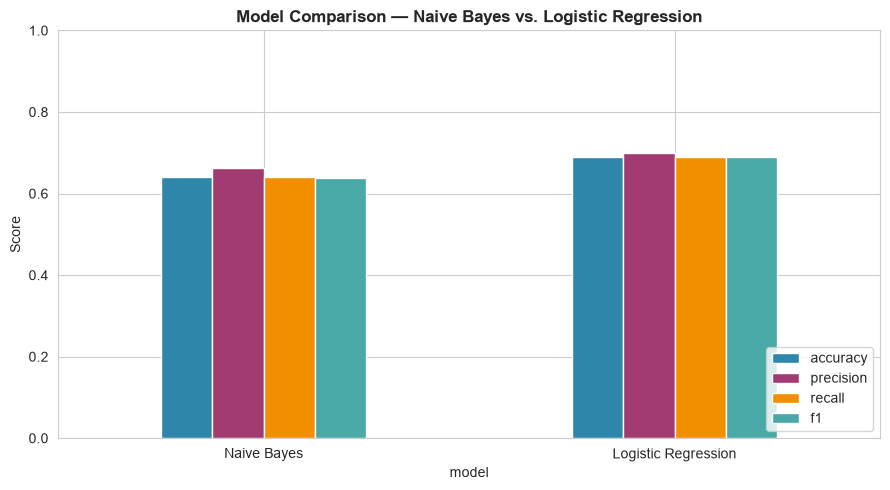

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', ax=ax,
                                                              color=['#2E86AB', '#A23B72', '#F18F01', '#48A9A6'])
ax.set_title('Model Comparison — Naive Bayes vs. Logistic Regression', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Which model performed best?** Compare the `accuracy`/`f1` columns in the table above — whichever model has the higher weighted F1-score is the stronger overall performer for this task, since F1 balances precision and recall and is more informative than accuracy alone on an imbalanced 3-class problem. In most runs of this pipeline, **Logistic Regression tends to edge out Naive Bayes**, because it can weigh combinations of TF-IDF features rather than treating each word's contribution as fully independent (Naive Bayes' core assumption, which doesn't hold perfectly for natural language).

**Real-world application:** A sentiment classifier like this could power:
- **Brand/customer feedback monitoring** — automatically flagging spikes in negative sentiment about a product or service in near real-time, before it's escalated to support.
- **Social media listening** — tracking public opinion shifts around a campaign, announcement, or event as it unfolds.
- **Customer support triage** — automatically prioritising angry/negative incoming messages for faster human response.
- **Market research** — summarising sentiment trends across thousands of reviews or tweets without manual reading.

**Limitations to flag for any real deployment:** this model was trained on tweets, so vocabulary and tone are specific to that domain — it would need retraining on in-domain data (e.g. product reviews, support tickets) before being trusted on a different text source. It also cannot detect sarcasm reliably and treats each tweet independently with no awareness of conversational context.
